# Introduction

This notebook walks throught the production of Fig. 01, which plots winds, currents, and related statistics for a representative model snapshot.

## Imports

In [2]:
import sys
sys.path.append("../src")

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from cur_kinematics import compute_for_ds

from map_plot import (
    subset,
    add_arrow_to_axis,
    add_box_to_axis,
    make_three_panel_money_figure,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

We use the raw WAVEWATCH III (WW3) output to plot these maps.

In [22]:
data_path = Path('../data/raw_ww3/')

The currents are the same in the LVWD&CUR and HVWD&CUR configurations, so we only open the former.

In [52]:
ww3_lvwd = xr.open_dataset(data_path / 'lvwd.nc')
ww3_hvwd = xr.open_dataset(data_path / 'hvwd.nc')
ww3_lvwd_cur = xr.open_dataset(data_path / 'lvwd_cur.nc')

November 30, 2020 at 16:00 UTC was found to demonstrate wind- and current-driven variability in the Stokes drift very effectively. The spatial extent is nearly as large as the model domain, but is square, which is better for plotting.

In [53]:
timestep = '2020-11-30T16:00:00.000000000'

lons = slice(None, 240)
lats = slice(25, 45)

In [54]:
ww3_lvwd_plt = subset(ww3_lvwd, timestep, lons, lats)
ww3_hvwd_plt = subset(ww3_hvwd, timestep, lons, lats)
ww3_lvwd_cur_plt = subset(ww3_lvwd_cur, timestep, lons, lats)

We commpute current kinematic statistics for just this time slice.

In [55]:
cur_kinematics_plt = compute_for_ds(ww3_lvwd_cur_plt,
    u_name="ucur",
    v_name="vcur",
    lat_name="latitude",
    lon_name="longitude",
)

We close the datasets we are not using anymore.

In [58]:
ww3_lvwd.close(); del ww3_lvwd
ww3_hvwd.close(); del ww3_hvwd
ww3_lvwd_cur.close(); del ww3_lvwd_cur

# Variables to Plot

We compute and extract the relevant variables for Fig. 01.

In [59]:
# Wind-speed magnitudes in m/s
lvwd_plt = np.hypot(
    ww3_lvwd_plt["uwnd"],
    ww3_lvwd_plt["vwnd"],
)

hvwd_plt = np.hypot(
    ww3_hvwd_plt["uwnd"],
    ww3_hvwd_plt["vwnd"],
)

# Current-speed magnitude in cm/s
cur_plt = np.hypot(
    ww3_lvwd_cur_plt["ucur"],
    ww3_lvwd_cur_plt["vcur"],
) * 100

vort_plt = cur_kinematics_plt.normalized_vorticity
div_plt = cur_kinematics_plt.normalized_divergence

# Plotting

In [60]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],

    "font.size": 11,
    "font.weight": "bold",

    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "legend.fontsize": 9,

    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",

    "axes.linewidth": 0.8,
})

In [61]:
figure_ranges = {
    "wind": {
        "levels": np.linspace(1, 19, 30),
        "ticks": [2, 10, 18],
        "extend": "both",
    },
    "wind_diff_pct": {
        "levels": np.linspace(-10, 10, 30),
        "ticks": [-10,0,10],
        "extend": "both",
    },
    "current": {
        "levels": np.linspace(1, 70, 30),
        "ticks": [5, 35, 65],
        "extend": "both",
    },
    "vorticity": {
        "levels": np.linspace(-0.3, 0.3, 30),
        "ticks": [-0.2,0,0.2],
        "extend": "both",
    },
    "divergence": {
        "levels": np.linspace(-0.3, 0.3, 30),
        "ticks": [-0.2,0,0.2],
        "extend": "both",
    },
}

In [62]:
wind_forcing_panels = [
    {
        "data": lvwd_plt,
        "title": r"Low-Varianility Winds",
        "style": "wind",
    },
    {
        "data": hvwd_plt,
        "title": r"High-Variability Winds",
        "style": "wind",
    },
    {
        "data": 100 * ((hvwd_plt - lvwd_plt) / hvwd_plt),
        "title": r"HVWD-LVWD",
        "style": "wind_diff_pct",
    },
]

In [63]:
currents_forcing_panels = [
    {
        "data": cur_plt,
        "title": r"Currents",
        "style": "current",
    },
    {
        "data": vort_plt,
        "title": r"Vorticity",
        "style": "vorticity",
    },
    {
        "data": div_plt,
        "title": r"Divergence",
        "style": "divergence",
    },
]

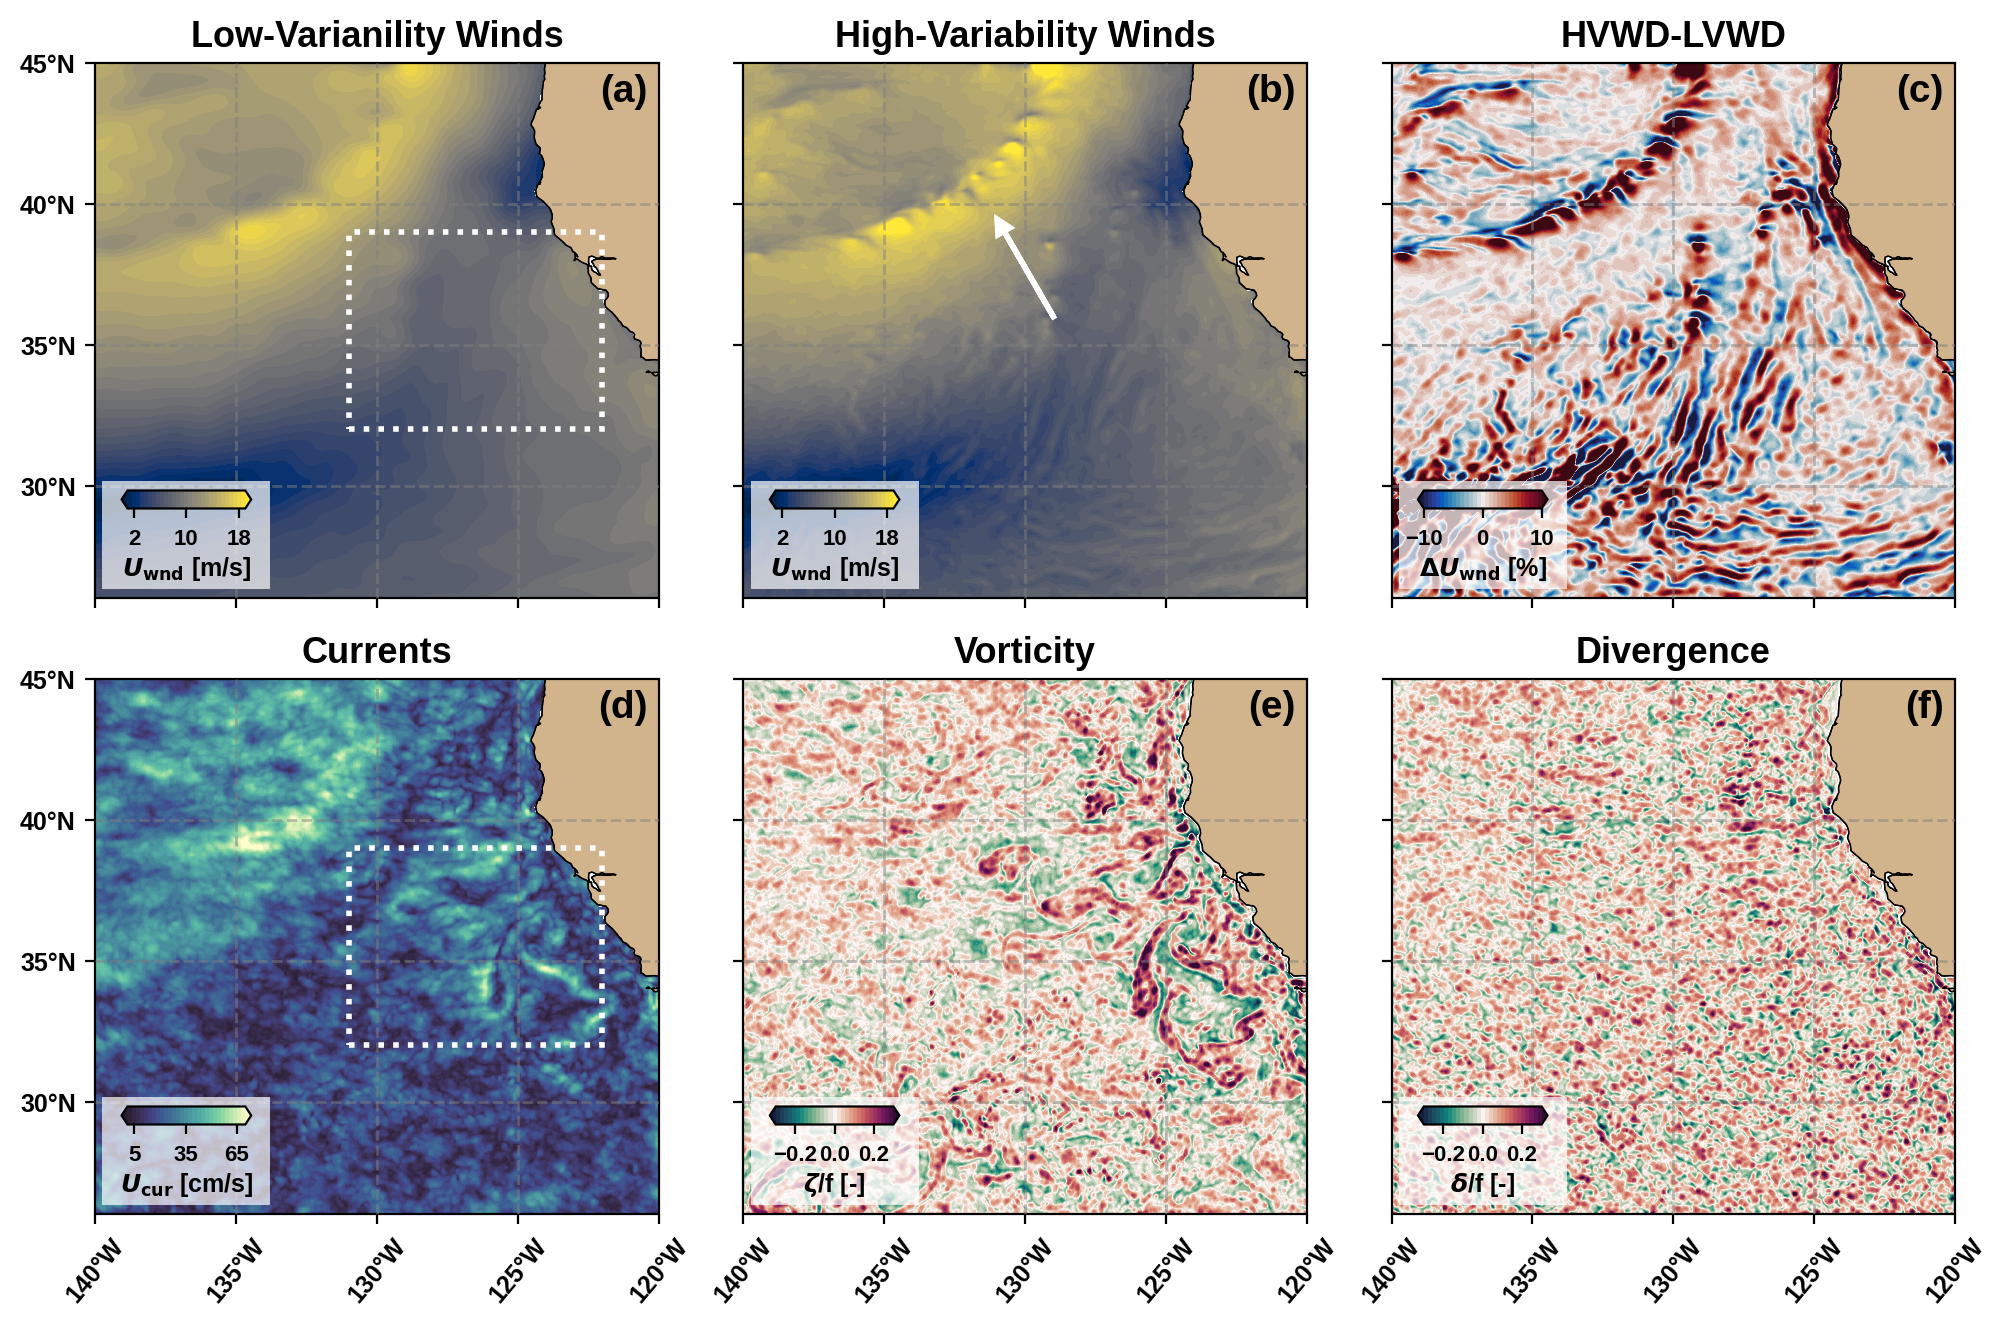

In [64]:
fig, axes = make_three_panel_money_figure(
    three_panel_rows=[
        wind_forcing_panels,
        currents_forcing_panels,
    ],
    ranges=figure_ranges,
    extent=[-140, -120, 26, 45],
    dpi=200
)

add_box_to_axis(
    axes[0][0],
    lon_min=-131,
    lon_max=-122,
    lat_min=32,
    lat_max=39,
)

add_box_to_axis(
    axes[1][0],
    lon_min=-131,
    lon_max=-122,
    lat_min=32,
    lat_max=39,
)

add_arrow_to_axis(axes[0][1], lat=36, lon=231, length=4, angle=120)

for row in axes:
    for ax in row:
        ax.title.set_fontsize(13)
        ax.title.set_fontweight("bold")

plt.show()

In [65]:
fig.savefig(
    '../figures/fig01.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)